<a href="https://colab.research.google.com/github/newts0fa/ml-basics/blob/main/_%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%9610_%D0%A0%D0%B0%D0%B7%D0%B2%D0%B5%D0%B4%D0%BE%D1%87%D0%BD%D1%8B%D0%B9_%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7%2C_%D0%BF%D1%80%D0%B5%D0%B4%D0%BE%D0%B1%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%BA%D0%B0_%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D1%85_%D0%B8_%D0%BE%D0%B1%D1%83%D1%87%D0%B5%D0%BD%D0%B8%D0%B5_%D0%BC%D0%BE%D0%B4%D0%B5%D0%BB%D0%B5%D0%B9_%D0%BA%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D0%B8_ipynb_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №10. Разведочный анализ, предобработка данных и обучение моделей классификации**

*(на примере датасета Bank Marketing)*

---

## ****Введение**** Воронов Илья 2024-ФГИИБ-ПИ-1Б


**Цель работы:** Обучить модель машинного обучения для предсказания, откроет ли клиент банка срочный вклад по результатам маркетинговой кампании (целевая переменная `y`: "yes" — откроет, "no" — не откроет).

**Датасет:** [Bank Marketing Dataset](https://archive.ics.uci.edu/dataset/222/bank+marketing) — данные о маркетинговых кампаниях португальского банка.

**Что вы научитесь делать:**
- Загружать и исследовать данные
- Выявлять проблемы через разведочный анализ (EDA)
- Анализировать и обрабатывать пропущенные значения
- Формулировать и **экспериментально проверять** гипотезы
- Создавать новые признаки (Feature Engineering)
- **Сравнивать все изученные методы классификации**
- **Выбирать лучшие модели и оптимизировать их гиперпараметры с помощью GridSearchCV**
- **Анализировать влияние комбинаций признаков на качество модели**

---

## ****Часть 1. Настройка окружения****

> 📚 **Подсказка:** Аналогичная настройка рассматривалась в [**Занятии 1, Часть 1** и **Занятии 2, Часть 1**](https://colab.research.google.com/drive/1Cnp7hPUUu5dorlhPPHUeztnnoq5Z2j4W?usp=sharing#scrollTo=5f49d9aa).

In [ ]:
# Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, roc_auc_score, roc_curve, confusion_matrix,
                            classification_report)

# Модели классификации
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              AdaBoostClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Отбор признаков
from sklearn.feature_selection import RFE, SelectKBest, f_classif
from itertools import combinations

# Настройки отображения
sns.set_style("whitegrid")
pd.set_option('display.max_columns', 20)

---

## ****Часть 2. Загрузка и первичный осмотр данных****

> 📚 **Подсказка:** Методы первичного осмотра (`head()`, `info()`, `describe()`, `shape`) подробно разобраны в [**Занятии 1, Часть 3.2**](https://colab.research.google.com/drive/1Cnp7hPUUu5dorlhPPHUeztnnoq5Z2j4W?usp=sharing#scrollTo=9ef7543b) и [**Занятии 2, Часть 2.1**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=43b439e3).

### ****Задание 2.1. Загрузите датасет****

In [ ]:
# Загрузка датасета Bank Marketing
url = "https://raw.githubusercontent.com/rishabhathiya/Bank-Marketing/refs/heads/main/bank.csv"
bank = pd.read_csv(url, sep=';')

# ВАЖНО: В этом датасете пропуски записаны как "unknown"
# Заменяем их на NaN, чтобы isna() корректно их определял
bank = bank.replace('unknown', np.nan)

bank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,NaN,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,NaN,3,jun,199,4,-1,0,NaN,no
4,59,blue-collar,married,secondary,no,0,yes,no,NaN,5,may,226,1,-1,0,NaN,no


### ****Задание 2.2. Изучите структуру данных****

**1. Выведите размерность датасета:**

In [ ]:
bank.shape


(4521, 17)

**2. Отобразите первые 10 строк датасета**

In [ ]:
bank.head(10)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,NaN,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,NaN,3,jun,199,4,-1,0,NaN,no
4,59,blue-collar,married,secondary,no,0,yes,no,NaN,5,may,226,1,-1,0,NaN,no
5,35,management,single,tertiary,no,747,no,no,cellular,23,feb,141,2,176,3,failure,no
6,36,self-employed,married,tertiary,no,307,yes,no,cellular,14,may,341,1,330,2,other,no
7,39,technician,married,secondary,no,147,yes,no,cellular,6,may,151,2,-1,0,NaN,no
8,41,entrepreneur,married,tertiary,no,221,yes,no,NaN,14,may,57,2,-1,0,NaN,no
9,43,services,married,primary,no,-88,yes,yes,cellular,17,apr,313,1,147,2,failure,no


**3. Выведите информацию о типах данных и пропусках**

In [ ]:
bank.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4483 non-null   object
 2   marital    4521 non-null   object
 3   education  4334 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    3197 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   816 non-null    object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


**4. Выведите статистику числовых признаков**

In [ ]:
bank.describe()


,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


**5. Выведите названия всех столбцов в виде списка строк**

In [ ]:
list(bank.columns)


['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'y']

### ****Задание 2.3. Ответьте на вопросы****

---

> 📝 **Как отвечать на текстовые вопросы?** Дважды кликните на ячейку → впишите ответ → нажмите `Shift+Enter`

---

**Вопрос 1:** Сколько записей (клиентов) в датасете?

**Ответ:** 4521 запись.

**Вопрос 2:** Сколько признаков (столбцов)?

**Ответ:** 17 исходных столбцов.

**Вопрос 3:** Какая переменная является целевой (что предсказываем)?

**Ответ:** Целевая переменная — `y`: откроет ли клиент срочный депозит (`yes`/`no`).

**Вопрос 4:** Какие типы данных преобладают — числовые или категориальные?

**Ответ:** Категориальных признаков больше: 10 категориальных против 7 числовых.

---


### ****Описание столбцов датасета Bank Marketing****

| Столбец | Описание | Тип |
|---------|----------|-----|
| `age` | Возраст клиента | Числовой |
| `job` | Тип занятости | Категориальный |
| `marital` | Семейное положение | Категориальный |
| `education` | Уровень образования | Категориальный |
| `default` | Есть ли дефолт по кредиту | Категориальный |
| `balance` | Баланс на счёте (евро) | Числовой |
| `housing` | Есть ли ипотека | Категориальный |
| `loan` | Есть ли личный кредит | Категориальный |
| `contact` | Тип связи | Категориальный |
| `day` | День последнего контакта | Числовой |
| `month` | Месяц последнего контакта | Категориальный |
| `duration` | Длительность последнего звонка (сек) | Числовой |
| `campaign` | Кол-во контактов в этой кампании | Числовой |
| `pdays` | Дней с последнего контакта (-1 = не было) | Числовой |
| `previous` | Кол-во контактов до этой кампании | Числовой |
| `poutcome` | Результат прошлой кампании | Категориальный |
| `y` | **Целевая переменная:** открыл ли вклад | Категориальный |

---

## ****Часть 3. Разведочный анализ данных (EDA)****

> 📚 **Подсказка:** Цель EDA — выявить проблемы в данных и найти закономерности (паттерны). Методология описана в [**Занятии 2, Часть 2**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=29f19e7a).

### ****3.1. Анализ целевой переменной (баланс классов)****

> 📚 **Подсказка:** Анализ баланса классов рассмотрен в [**Занятии 2, Часть 2.3**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=15c684d7).

In [ ]:
# Создаём числовую версию целевой переменной в столбце target
bank['target'] = (bank['y'] == 'yes').astype(int)

bank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,target
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,NaN,no,0
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no,0
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no,0
3,30,management,married,tertiary,no,1476,yes,yes,NaN,3,jun,199,4,-1,0,NaN,no,0
4,59,blue-collar,married,secondary,no,0,yes,no,NaN,5,may,226,1,-1,0,NaN,no,0


**Подсчитайте распределение целевой переменной 'y'**

In [ ]:
bank['y'].value_counts()


,count
y,
no,4000
yes,521


**Вопрос:** сколько клиентов открыли депозит (yes)? сколько не открыли (no)?

**Ответ:** депозит открыли 521 клиент, не открыли — 4000 клиентов.

---

**Визуализируйте распределения классов графически (постройте столбчатую (barplot) или круговую (pie chart) диаграмму)**


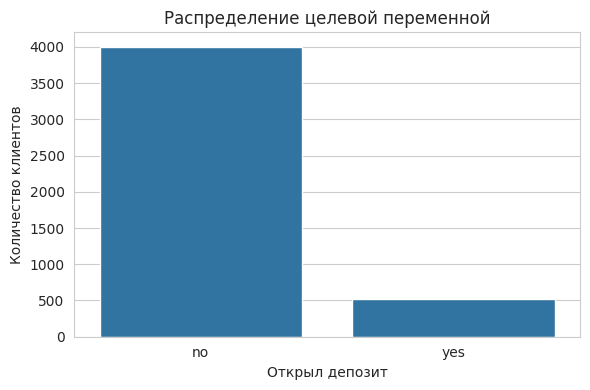

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=bank, x='y', order=['no', 'yes'])
plt.title('Распределение целевой переменной')
plt.xlabel('Открыл депозит')
plt.ylabel('Количество клиентов')
plt.tight_layout()
plt.show()


---

**Вычислите процент клиентов, открывших вклад**

In [ ]:
deposit_rate = bank['target'].mean() * 100
print(f'Процент клиентов, открывших вклад: {deposit_rate:.2f}%')


Процент клиентов, открывших вклад: 11.52%


**Вопрос:** Сбалансированы ли классы? Какой класс преобладает?

**Ответ:** классы несбалансированы: положительный класс `yes` занимает около 11.5%, отрицательный класс `no` — около 88.5%. Сильно преобладает класс `no`.

---


### ****3.2. Анализ пропущенных значений****

> 📚 **Подсказка:** Проверка пропусков с помощью `isna().sum()` показана в [**Занятии 1, Часть 3.6**](https://colab.research.google.com/drive/1Cnp7hPUUu5dorlhPPHUeztnnoq5Z2j4W?usp=sharing#scrollTo=1f244634) и [**Занятии 2, Часть 2.2**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=e96e5f15).

**Проверьте наличие пропущенных значений в датасете с помощью `isna().sum()`**

In [ ]:
missing_count = bank.isna().sum().sort_values(ascending=False)
missing_count[missing_count > 0]


,0
poutcome,3705
contact,1324
education,187
job,38


**Вычислите процент пропущенных значений в каждом столбце датасета**

In [ ]:
missing_percent = (bank.isna().mean() * 100).sort_values(ascending=False)
missing_percent[missing_percent > 0]


,0
poutcome,81.950896
contact,29.285556
education,4.136253
job,0.840522


**Постройте столбчатую диаграмму (`barplot`) для визуализации процента пропусков**

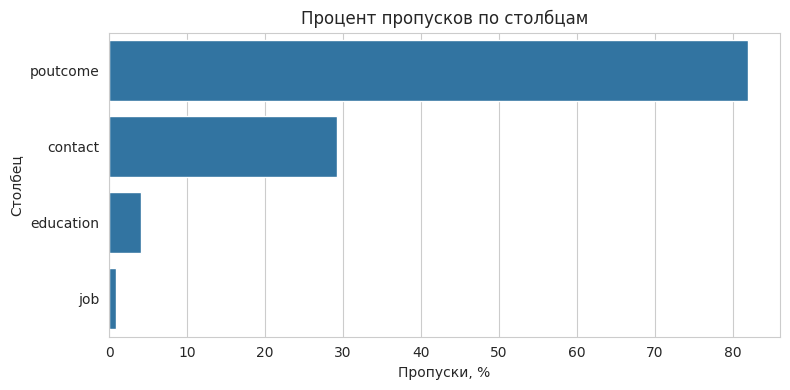

In [ ]:
missing_percent_plot = missing_percent[missing_percent > 0]

plt.figure(figsize=(8, 4))
sns.barplot(x=missing_percent_plot.values, y=missing_percent_plot.index)
plt.title('Процент пропусков по столбцам')
plt.xlabel('Пропуски, %')
plt.ylabel('Столбец')
plt.tight_layout()
plt.show()


**Вопрос:** В каких столбцах больше всего пропусков? Какой процент данных потеряем, если удалим все строки с пропусками?

**Ответ:** больше всего пропусков в `poutcome` (около 82%), затем в `contact` (около 29%), `education` (около 4%) и `job` (менее 1%). При удалении всех строк с пропусками потеряем примерно 82% данных, поэтому удаление строк — плохая стратегия.

---


### ****3.3. Анализ числовых признаков****

> 📚 **Подсказка:** Построение гистограмм с разбивкой по целевой переменной (`hue`) показано в [**Занятии 2, Часть 2.4**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=ea28aa58).

**Обязательно постройте гистограммы для следующих признаков:**
- `age` — возраст
- `balance` — баланс на счёте  
- `duration` — длительность звонка

**Постройте гистограммы для числовых признаков с разбивкой по целевой переменной**

> Используйте `sns.histplot()` с параметром `hue='target'`

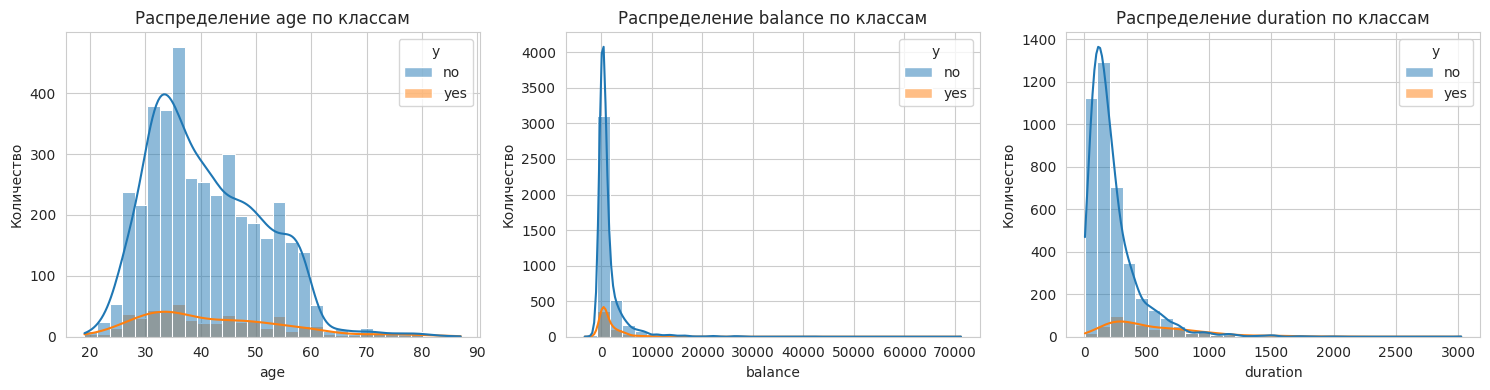

In [ ]:
numeric_features = ['age', 'balance', 'duration']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(numeric_features):
    sns.histplot(data=bank, x=col, hue='y', bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'Распределение {col} по классам')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Количество')

plt.tight_layout()
plt.show()


*(При желании, можете не использовать мои шаблоны, а написать код для построения графиков с нуля и самостоятельно)*

**Вопрос:** Какие наблюдения вы можете сделать? Какие признаки различаются для клиентов, открывших и не открывших вклад?

**Ответ:** сильнее всего различается `duration`: у клиентов, которые открыли вклад, длительность контакта обычно выше. `balance` у положительного класса часто немного выше, но распределение шумное. `age` различается слабее: явного линейного разделения по возрасту нет.

---


### ****Задание 3.4. Анализ категориальных признаков****

> 📚 **Подсказка:** Построение столбчатой диаграммы (`barplot`) для анализа связи категориальных признаков с целевой переменной показано в [**Занятии 2, Часть 2.5**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=ea6a781f).

**Постройте графики для анализа доли открывших депозит по категориальным признакам ('job', 'marital', 'education', 'contact'):**

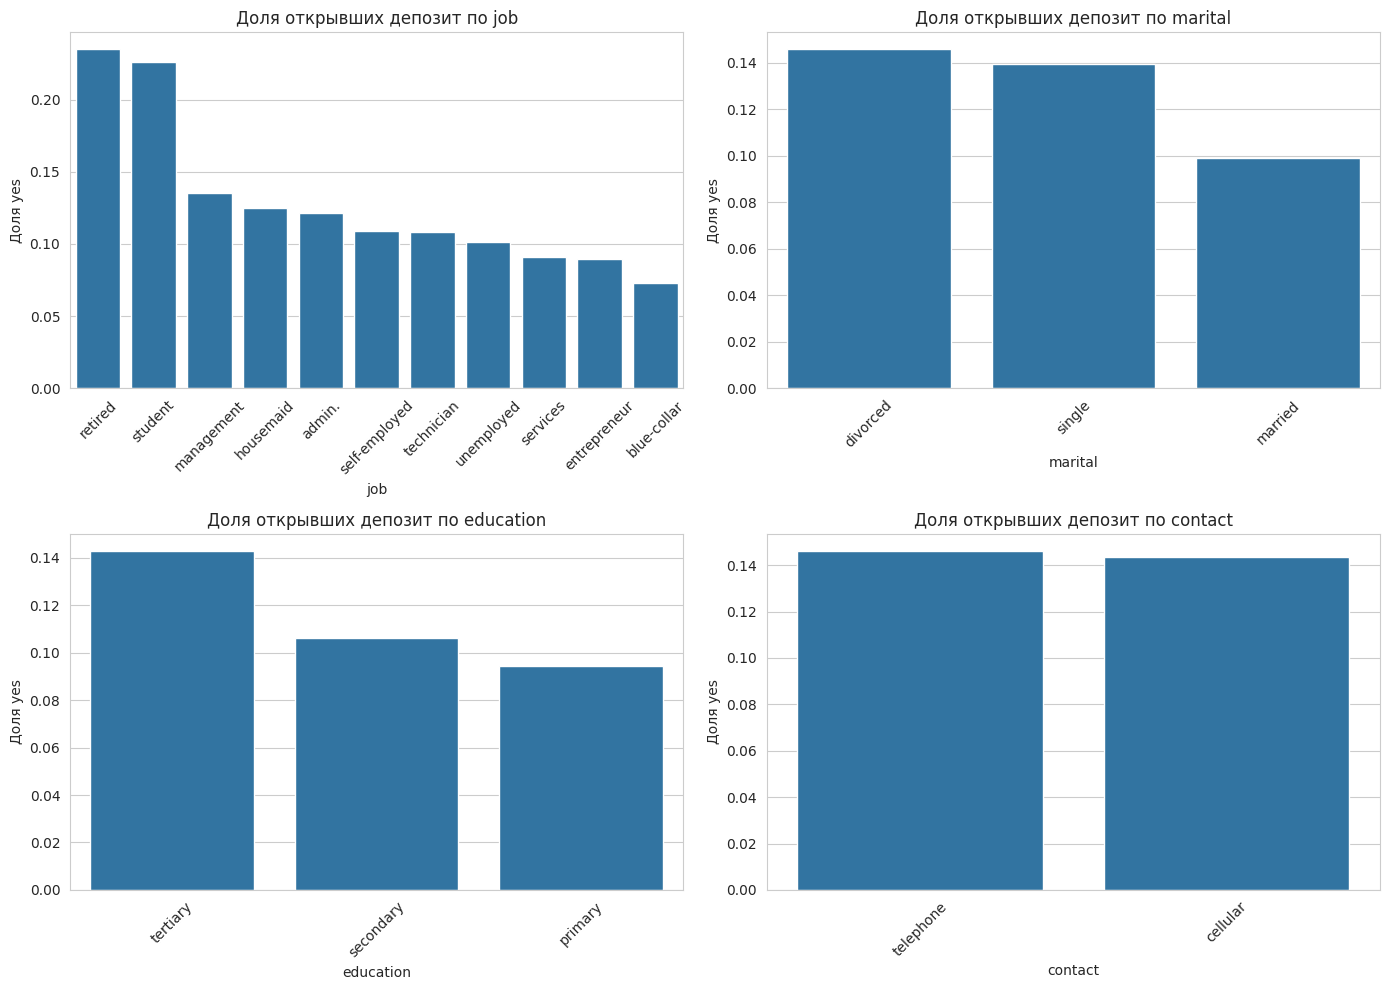

In [ ]:
cat_features = ['job', 'marital', 'education', 'contact']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    rates = bank.groupby(col)['target'].mean().sort_values(ascending=False).reset_index()
    sns.barplot(data=rates, x=col, y='target', ax=axes[i])
    axes[i].set_title(f'Доля открывших депозит по {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Доля yes')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


---

**Ответьте на вопросы:**

**Вопрос:** Люди каких профессий чаще открывают депозит?

**Ответ:** чаще всего депозит открывают группы `student` и `retired`, также неплохо выглядят `management` и `unemployed`.

**Вопрос:** Влияет ли семейное положение на вероятность открытия депозита?

**Ответ:** да, влияет: у клиентов со статусом `single` доля открытий обычно выше, чем у `married` и `divorced`.

**Вопрос:** Какой тип связи (contact) наиболее эффективен?

**Ответ:** наиболее эффективен `cellular`, у него выше доля положительных ответов.

**Вопрос:** Какие в общем категории клиентов чаще открывают вклад (примерный портрет по всем категориальным признакам в совокупности)?

**Ответ:** чаще откликаются клиенты с профессиями `student`/`retired`, не состоящие в браке, с более высоким уровнем образования и контактом через `cellular`.

---


### ****Задание 3.5. Анализ связей между признаками (Boxplot)****

> 📚 **Подсказка:** Использование boxplot для анализа распределений показано в [**Занятии 2, Часть 2.6**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=592b07cc).

**Постройте `boxplot` для анализа баланса по уровню образования**

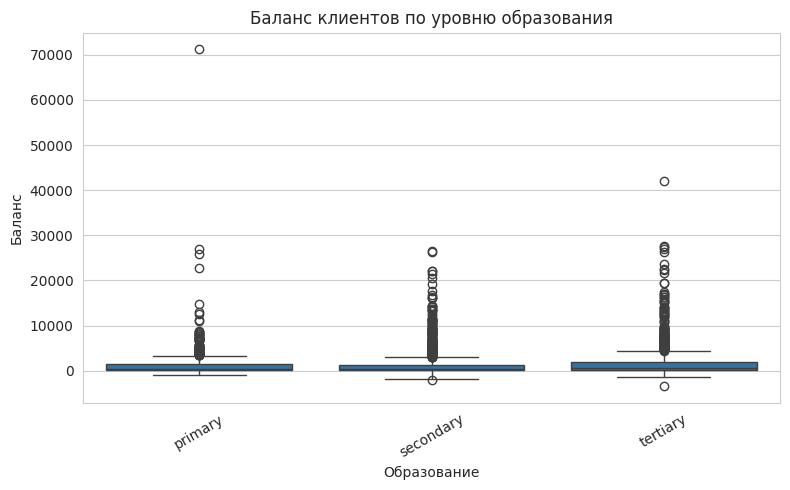

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=bank, x='education', y='balance')
plt.title('Баланс клиентов по уровню образования')
plt.xlabel('Образование')
plt.ylabel('Баланс')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


**Вопрос:** Различается ли баланс у клиентов с разным образованием?

**Ответ:** медианный баланс по группам образования различается не очень сильно, но разброс и выбросы заметны. У клиентов с `tertiary` баланс в среднем выглядит немного выше.

---


### ****Задание 3.6. Группировка данных****

> 📚 **Подсказка:** Метод `groupby()` подробно разобран в [**Занятии 1, Часть 3.7**](https://colab.research.google.com/drive/1Cnp7hPUUu5dorlhPPHUeztnnoq5Z2j4W?usp=sharing#scrollTo=baa512e4).

**Вычислите средний баланс и долю открывших депозит по типу работы**

In [ ]:
bank.groupby('education').agg(
    avg_balance=('balance', 'mean'),
    avg_age=('age', 'mean'),
    clients=('target', 'size')
).sort_values('avg_balance', ascending=False)


,avg_balance,avg_age,clients
education,,,
tertiary,1775.423704,39.645926,1350
primary,1411.544248,46.833333,678
secondary,1196.814397,40.062446,2306


**Вычислите долю открывших депозит по уровню образования**

In [ ]:
bank.groupby('education')['target'].mean().sort_values(ascending=False).to_frame('deposit_rate')


,deposit_rate
education,
tertiary,0.142963
secondary,0.106245
primary,0.094395


---

## ****Часть 4. Формулировка гипотез и план экспериментов****

> 📚 **Подсказка:** Формулировка гипотез на основе EDA описана в [**Занятии 2, Часть 3**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=329f49e7).

На основе проведённого EDA сформулируйте **минимум 3 гипотезы** о том, какие признаки и преобразования могут улучшить модель.

### ****Ваши гипотезы:****

| № | Наблюдение из EDA | Гипотеза | Как проверить | Метрика для сравнения |
|---|-------------------|----------|---------------|----------------------|
| 1 | `duration` заметно выше у клиентов с `yes` | Длительность контакта является одним из самых сильных признаков | Сравнить модели с `duration` и без него, посмотреть важность признаков | F1-score, ROC-AUC |
| 2 | Значение `pdays = -1` означает, что клиента раньше не контактировали | Бинарный признак `was_contacted` улучшит качество | Добавить `was_contacted` и сравнить с baseline | Accuracy, F1-score |
| 3 | В `contact`, `poutcome`, `education`, `job` есть пропуски | Сам факт пропуска может быть информативен | Создать индикаторы пропусков и сравнить качество | Accuracy, F1-score |

---


## ****Часть 5. Сравнение методов классификации****

> 📚 **Подсказка:** Различные методы классификации (логистическая регрессия, деревья решений, ансамбли, SVM, KNN) подробно разбирались на занятиях по supervised learning.

### ****5.1. Расширенная функция оценки модели****

> 📚 **Подсказка:** Базовая функция `evaluate_model()` была создана в [**Занятии 2, после Части 4.6**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=maxKagcsxhv8).

In [ ]:
def evaluate_model_advanced(model, X, y, model_name='Model'):
    # Расширенная оценка модели с множественными метриками.
    # Используется один train/test split, чтобы сравнение моделей было честным и быстрым.
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test_scaled)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_test_scaled)
    else:
        y_score = None

    roc_auc = roc_auc_score(y_test, y_score) if y_score is not None else np.nan

    results = {
        'model_name': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc
    }

    return results, y_test, y_pred, y_score


### ****5.2. Простая функция оценки (для быстрых экспериментов)****

In [ ]:
def evaluate_model(X, y):
    """
    Быстрая оценка модели логистической регрессии.
    Возвращает только accuracy.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = LogisticRegression(random_state=42, max_iter=1000)
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)

    return accuracy

### ****5.3. Подготовка данных для baseline****

In [ ]:
# Выбираем только числовые признаки для baseline
numeric_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

# Подготовьте X и y
X_baseline = bank[numeric_cols]
y_baseline = bank['target']

print(f"Размер X: {X_baseline.shape}")
print(f"Размер y: {y_baseline.shape}")

Размер X: (4521, 7)
Размер y: (4521,)


### ****5.4. Задание: Сравните ВСЕ методы классификации****

**Создайте словарь со всеми моделями:**

In [ ]:
# Словарь моделей для сравнения
# Параметры подобраны так, чтобы ноутбук быстро запускался в Colab.
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=80, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=80, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=80, random_state=42),
    'SVM': SVC(kernel='rbf', probability=False, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=9),
    'Naive Bayes': GaussianNB()
}


**Обучите все модели и соберите результаты:**

In [ ]:
from sklearn.base import clone

# Словарь для хранения всех результатов экспериментов
all_results = {}

# Список для сбора результатов сравнения моделей
comparison_results = []

print('=' * 70)
print('СРАВНЕНИЕ ВСЕХ МЕТОДОВ КЛАССИФИКАЦИИ (BASELINE)')
print('=' * 70)

for name, model in models.items():
    results, y_test_tmp, y_pred_tmp, y_score_tmp = evaluate_model_advanced(
        clone(model), X_baseline, y_baseline, name
    )
    comparison_results.append(results)
    all_results[f'baseline_{name}'] = results
    roc_text = f"{results['roc_auc']:.4f}" if not np.isnan(results['roc_auc']) else 'N/A'
    print(f"{name:25} | Accuracy: {results['accuracy']:.4f} | Precision: {results['precision']:.4f} | Recall: {results['recall']:.4f} | F1: {results['f1']:.4f} | ROC-AUC: {roc_text}")

print('=' * 70)


СРАВНЕНИЕ ВСЕХ МЕТОДОВ КЛАССИФИКАЦИИ (BASELINE)
Logistic Regression       | Accuracy: 0.8862 | Precision: 0.5161 | Recall: 0.1538 | F1: 0.2370 | ROC-AUC: 0.8162
Decision Tree             | Accuracy: 0.8829 | Precision: 0.4865 | Recall: 0.3462 | F1: 0.4045 | ROC-AUC: 0.8146
Random Forest             | Accuracy: 0.8729 | Precision: 0.3962 | Recall: 0.2019 | F1: 0.2675 | ROC-AUC: 0.8471
Gradient Boosting         | Accuracy: 0.8818 | Precision: 0.4769 | Recall: 0.2981 | F1: 0.3669 | ROC-AUC: 0.8496
AdaBoost                  | Accuracy: 0.8785 | Precision: 0.4400 | Recall: 0.2115 | F1: 0.2857 | ROC-AUC: 0.8436
SVM                       | Accuracy: 0.8873 | Precision: 0.5556 | Recall: 0.0962 | F1: 0.1639 | ROC-AUC: 0.7408
KNN                       | Accuracy: 0.8895 | Precision: 0.5455 | Recall: 0.2308 | F1: 0.3243 | ROC-AUC: 0.7600
Naive Bayes               | Accuracy: 0.8575 | Precision: 0.3786 | Recall: 0.3750 | F1: 0.3768 | ROC-AUC: 0.8009


<details>
<summary><b>Подсказка (код):</b></summary>

In [ ]:
# Подсказка-дубликат: рабочий вариант цикла сравнения моделей
# Эту ячейку можно не запускать отдельно, основной цикл выше уже заполняет comparison_results.

# comparison_results = []
# for name, model in models.items():
#     results, _, _, _ = evaluate_model_advanced(clone(model), X_baseline, y_baseline, name)
#     comparison_results.append(results)
#     roc_text = f"{results['roc_auc']:.4f}" if not np.isnan(results['roc_auc']) else 'N/A'
#     print(f"{name:25} | Accuracy: {results['accuracy']:.4f} | F1: {results['f1']:.4f} | ROC-AUC: {roc_text}")


</details>

### ****5.5. Создайте DataFrame с результатами и визуализируйте****

In [ ]:
# Создайте DataFrame из comparison_results
df_comparison = pd.DataFrame(comparison_results)

# Отсортируйте по F1-score
df_comparison = df_comparison.sort_values('f1', ascending=False).reset_index(drop=True)

# Выведите таблицу
df_comparison


,model_name,accuracy,precision,recall,f1,roc_auc
0,Decision Tree,0.882873,0.486486,0.346154,0.404494,0.814637
1,Naive Bayes,0.857459,0.378641,0.375000,0.376812,0.800862
2,Gradient Boosting,0.881768,0.476923,0.298077,0.366864,0.849563
3,KNN,0.889503,0.545455,0.230769,0.324324,0.759958
4,AdaBoost,0.878453,0.440000,0.211538,0.285714,0.843597
5,Random Forest,0.872928,0.396226,0.201923,0.267516,0.847066
6,Logistic Regression,0.886188,0.516129,0.153846,0.237037,0.816191
7,SVM,0.887293,0.555556,0.096154,0.163934,0.740781


**Постройте визуализацию сравнения моделей:**

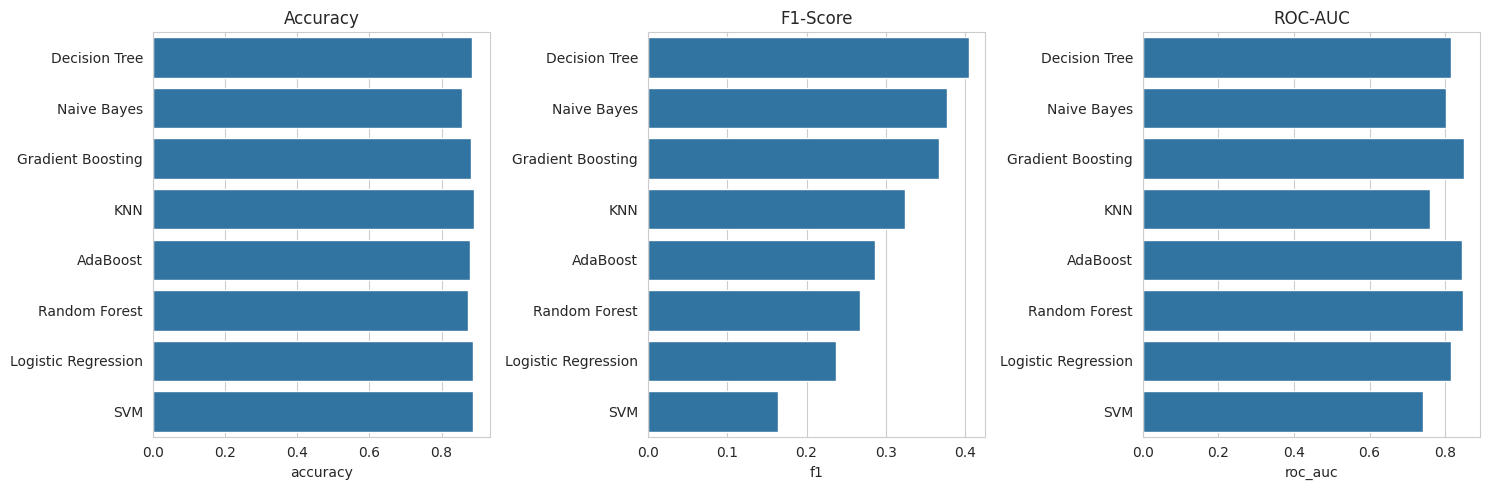

In [ ]:
# Постройте barplot для сравнения моделей по разным метрикам
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics_to_plot = ['accuracy', 'f1', 'roc_auc']
titles = ['Accuracy', 'F1-Score', 'ROC-AUC']

for i, (metric, title) in enumerate(zip(metrics_to_plot, titles)):
    sns.barplot(data=df_comparison, x=metric, y='model_name', ax=axes[i])
    axes[i].set_title(title)
    axes[i].set_xlabel(metric)
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()


### ****5.6. Ответьте на вопросы****

**Вопрос:** Какие 3 модели показали лучший результат по F1-Score?

**Ответ:** на baseline-наборе (только числовые признаки) топ-3 по F1-Score: `Decision Tree` — 0.4045, `Naive Bayes` — 0.3768, `Gradient Boosting` — 0.3669.

**Вопрос:** Почему мы ориентируемся на F1-Score, а не на Accuracy? (Подсказка: вспомните баланс классов)

**Ответ:** классы сильно несбалансированы: около 88.5% клиентов не открывают депозит, и только около 11.5% открывают. Accuracy может быть высокой даже у модели, которая почти всегда предсказывает `no`, поэтому для положительного класса `yes` важнее F1-score: он учитывает и precision, и recall.

**Вопрос:** Какая модель показала лучший ROC-AUC? Что это означает?

**Ответ:** лучший ROC-AUC на baseline показал `Gradient Boosting` — 0.8496. Это означает, что модель лучше остальных ранжирует клиентов по вероятности открытия депозита: клиенты с `yes` чаще получают более высокий скор, чем клиенты с `no`.

---


## ****Часть 6. Стратегии обработки пропусков****

> 📚 **Подсказка:** Стратегии заполнения пропусков (удаление, заполнение модой/медианой, создание признаков) подробно разобраны в [**Занятии 2, Часть 5**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=89cec4d9).

### ****6.1. Стратегия A: Удаление строк с пропусками****

In [ ]:
# Посмотрим, сколько данных потеряем
df_dropped = bank.dropna()

print(f"Было строк: {len(bank)}")
print(f"Стало строк: {len(df_dropped)}")
print(f"Потеряно: {len(bank) - len(df_dropped)} ({(len(bank) - len(df_dropped)) / len(bank) * 100:.1f}%)")

Было строк: 4521
Стало строк: 764
Потеряно: 3757 (83.1%)


**Вопрос:** Приемлемо ли терять столько данных?

**Ответ:** нет, это неприемлемо: при удалении строк с пропусками теряется большая часть датасета, в основном из-за столбца `poutcome`. Лучше заполнять пропуски и/или создавать индикаторы пропусков.

---


### ****6.2. Стратегия B: Заполнение модой****

> 📚 **Подсказка:** Заполнение пропусков модой через `fillna()` рассматривалось в [**Занятии 2, Часть 5, Стратегия B**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=8e470458).

**Заполните категориальные пропуски модой (самым частым значением)**

In [ ]:
df_filled = bank.copy()

cat_cols_with_na = ['job', 'education', 'contact', 'poutcome']

for col in cat_cols_with_na:
    if df_filled[col].isna().sum() > 0:
        mode_value = df_filled[col].mode()[0]
        df_filled[col] = df_filled[col].fillna(mode_value)
        print(f'{col}: пропуски заполнены модой "{mode_value}"')

print(f"Пропусков после заполнения: {df_filled.isna().sum().sum()}")


job: пропуски заполнены модой "management"
education: пропуски заполнены модой "secondary"
contact: пропуски заполнены модой "cellular"
poutcome: пропуски заполнены модой "failure"
Пропусков после заполнения: 0


### ****6.3. Стратегия C: Создание признаков из пропусков****

> 📚 **Подсказка:** Создание бинарных признаков из пропусков (например, `has_cabin` в Titanic) рассматривалось в [**Занятии 2, Часть 6, Эксперимент 2, Тест D**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=df9d9180).
>
> **Идея:** Сам факт того, что значение неизвестно, может быть информативен! Например: если клиент не указал профессию — это может что-то говорить о нём.

**Создайте признаки "был ли пропуск" ДО заполнения**

In [ ]:
df_fe = bank.copy()

# Создаём бинарные индикаторы пропусков: 1 — значение было пропущено, 0 — не было.
for col in ['job', 'education', 'contact', 'poutcome']:
    df_fe[f'{col}_unknown'] = bank[col].isna().astype(int)

print(df_fe[['job_unknown', 'education_unknown', 'contact_unknown', 'poutcome_unknown']].head())


   job_unknown  education_unknown  contact_unknown  poutcome_unknown
0            0                  0                0                 1
1            0                  0                0                 0
2            0                  0                0                 0
3            0                  0                1                 1
4            0                  0                1                 1


---

## ****Часть 7. Feature Engineering и отбор признаков****

> 📚 **Подсказка:** Создание новых признаков на основе анализа данных описано в [**Занятии 2, Часть 6**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=28a74583).

### ****7.1. Создание новых признаков****

**Создайте следующие признаки на основе гипотез из EDA:**

In [ ]:
df_fe = bank.copy()

# 1. Был ли клиент контактирован ранее (pdays != -1)
df_fe['was_contacted'] = (bank['pdays'] != -1).astype(int)

# 2. Положительный баланс
df_fe['has_positive_balance'] = (bank['balance'] > 0).astype(int)

# 3. Признаки из пропусков (ДО заполнения!)
df_fe['job_unknown'] = bank['job'].isna().astype(int)
df_fe['education_unknown'] = bank['education'].isna().astype(int)
df_fe['contact_unknown'] = bank['contact'].isna().astype(int)
df_fe['poutcome_unknown'] = bank['poutcome'].isna().astype(int)

# Теперь заполняем пропуски
for col in ['job', 'education', 'contact', 'poutcome']:
    if df_fe[col].isna().sum() > 0:
        mode_value = df_fe[col].mode()[0]
        df_fe[col] = df_fe[col].fillna(mode_value)

print('Созданные признаки:')
print(df_fe[['was_contacted', 'has_positive_balance', 'job_unknown', 'education_unknown', 'contact_unknown', 'poutcome_unknown']].head(10))


Созданные признаки:
   was_contacted  has_positive_balance  job_unknown  education_unknown  \
0              0                     1            0                  0   
1              1                     1            0                  0   
2              1                     1            0                  0   
3              0                     1            0                  0   
4              0                     0            0                  0   
5              1                     1            0                  0   
6              1                     1            0                  0   
7              0                     1            0                  0   
8              0                     1            0                  0   
9              1                     0            0                  0   

   contact_unknown  poutcome_unknown  
0                0                 1  
1                0                 0  
2                0                 0  
3        

**Добавьте свои признаки на основе ваших гипотез:**

In [ ]:
# Дополнительные признаки на основе EDA
df_fe['long_call'] = (df_fe['duration'] > df_fe['duration'].median()).astype(int)
df_fe['many_contacts_campaign'] = (df_fe['campaign'] > df_fe['campaign'].median()).astype(int)
df_fe['balance_per_age'] = df_fe['balance'] / df_fe['age'].replace(0, np.nan)
df_fe['balance_per_age'] = df_fe['balance_per_age'].fillna(0)

print(df_fe[['long_call', 'many_contacts_campaign', 'balance_per_age']].head())


   long_call  many_contacts_campaign  balance_per_age
0          0                       0        59.566667
1          1                       0       145.121212
2          0                       0        38.571429
3          1                       1        49.200000
4          1                       0         0.000000


### ****7.2. Систематический перебор комбинаций признаков****

> **Цель:** Определить, какие признаки улучшают модель, а какие вносят шум.

**Определите базовый набор признаков и признаки для тестирования:**

In [ ]:
# Базовые числовые признаки
base_features = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'day']

# Новые созданные признаки для тестирования
new_features = ['was_contacted', 'has_positive_balance', 'job_unknown',
                'education_unknown', 'contact_unknown', 'poutcome_unknown',
                'long_call', 'many_contacts_campaign', 'balance_per_age']

# Оценим базовую модель
X_base = df_fe[base_features]
y = df_fe['target']

accuracy_base = evaluate_model(X_base, y)
print(f"Базовая модель ({len(base_features)} признаков): Accuracy = {accuracy_base:.4f}")
print(f"Признаки: {base_features}")
print('=' * 60)


Базовая модель (7 признаков): Accuracy = 0.8862
Признаки: ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'day']


**Протестируйте добавление каждого нового признака по отдельности:**

In [ ]:
feature_test_results = []

for feature in new_features:
    current_features = base_features + [feature]
    accuracy = evaluate_model(df_fe[current_features], y)
    feature_test_results.append({
        'feature': feature,
        'accuracy': accuracy,
        'delta_accuracy': accuracy - accuracy_base
    })

feature_test_df = pd.DataFrame(feature_test_results).sort_values('delta_accuracy', ascending=False)
feature_test_df


,feature,accuracy,delta_accuracy
0,was_contacted,0.891713,0.005525
5,poutcome_unknown,0.891713,0.005525
6,long_call,0.887293,0.001105
1,has_positive_balance,0.886188,0.000000
2,job_unknown,0.886188,0.000000
8,balance_per_age,0.886188,0.000000
3,education_unknown,0.886188,0.000000
7,many_contacts_campaign,0.885083,-0.001105
4,contact_unknown,0.881768,-0.004420


**Вопрос:** Какие признаки улучшили модель? Какие ухудшили (внесли шум)?

**Ответ:** по таблице `feature_test_df` качество улучшили `was_contacted` и `poutcome_unknown` (+0.0055 к accuracy), а также немного `long_call` (+0.0011). Признаки `has_positive_balance`, `job_unknown`, `education_unknown` и `balance_per_age` почти не изменили результат. Хуже стало от `many_contacts_campaign` (-0.0011) и особенно от `contact_unknown` (-0.0044), значит в этом простом эксперименте они добавили шум.


### ****7.3. Анализ важности признаков с помощью Random Forest****

ВАЖНОСТЬ ПРИЗНАКОВ (Random Forest)
               feature  importance
              duration    0.280955
                   age    0.128045
       balance_per_age    0.125055
               balance    0.123548
                   day    0.108494
                 pdays    0.065652
              campaign    0.042871
             long_call    0.040717
              previous    0.024881
       contact_unknown    0.015881
many_contacts_campaign    0.012195
         was_contacted    0.009620
     education_unknown    0.007511
      poutcome_unknown    0.006759
  has_positive_balance    0.005070
           job_unknown    0.002746


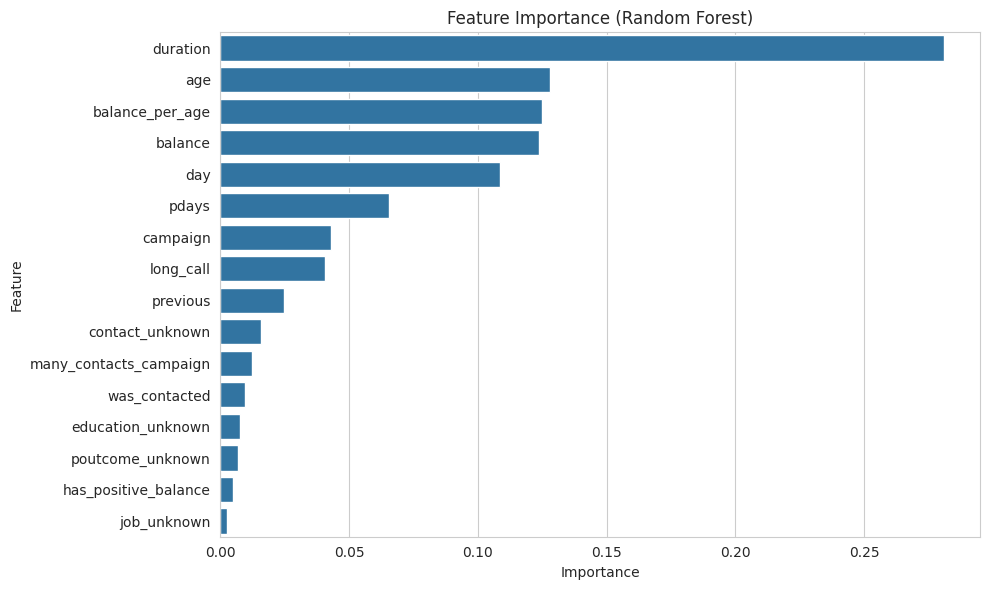

In [ ]:
# Соберём все признаки
all_numeric_features = base_features + new_features
X_all = df_fe[all_numeric_features]

# Обучим Random Forest и посмотрим важность признаков
from sklearn.ensemble import RandomForestClassifier

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

# Обучение
rf = RandomForestClassifier(n_estimators=80, random_state=42, n_jobs=-1)
rf.fit(X_scaled, y)

# Важность признаков
importance_df = pd.DataFrame({
    'feature': all_numeric_features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print('ВАЖНОСТЬ ПРИЗНАКОВ (Random Forest)')
print('=' * 40)
print(importance_df.to_string(index=False))
print('=' * 40)

# Визуализация
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


### ****7.4. Рекурсивное исключение признаков (RFE)****

> 📚 **Подсказка:** [RFE](https://habr.com/ru/companies/otus/articles/528676/) автоматически отбирает наиболее важные признаки, последовательно удаляя наименее значимые.

In [ ]:
from sklearn.feature_selection import RFE

# Применяем RFE для отбора лучших признаков
selector = RFE(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    n_features_to_select=7,  # Отберём 7 лучших признаков
    step=1
)

selector.fit(X_scaled, y)

# Какие признаки отобраны?
selected_features = [f for f, s in zip(all_numeric_features, selector.support_) if s]
rejected_features = [f for f, s in zip(all_numeric_features, selector.support_) if not s]

print("РЕЗУЛЬТАТЫ RFE")
print("=" * 40)
print(f"Отобранные признаки ({len(selected_features)}): {selected_features}")
print(f"Отвергнутые признаки ({len(rejected_features)}): {rejected_features}")
print("=" * 40)

# Сравним accuracy
X_selected = df_fe[selected_features]
accuracy_selected = evaluate_model(X_selected, y)
accuracy_all = evaluate_model(X_all, y)

print(f"\nAccuracy (все {len(all_numeric_features)} признаков): {accuracy_all:.4f}")
print(f"Accuracy (отобранные {len(selected_features)} признаков): {accuracy_selected:.4f}")
print(f"Разница: {accuracy_selected - accuracy_all:+.4f}")

РЕЗУЛЬТАТЫ RFE
Отобранные признаки (7): ['balance', 'duration', 'pdays', 'was_contacted', 'contact_unknown', 'poutcome_unknown', 'long_call']
Отвергнутые признаки (9): ['age', 'campaign', 'previous', 'day', 'has_positive_balance', 'job_unknown', 'education_unknown', 'many_contacts_campaign', 'balance_per_age']

Accuracy (все 16 признаков): 0.8851
Accuracy (отобранные 7 признаков): 0.8884
Разница: +0.0033


**Вопрос:** Помог ли отбор признаков улучшить модель? Какие признаки оказались лишними?

**Ответ:** да, RFE немного улучшил accuracy: со всеми 16 числовыми признаками было 0.8851, с 7 отобранными признаками стало 0.8884, прирост составил +0.0033. RFE оставил `balance`, `duration`, `pdays`, `was_contacted`, `contact_unknown`, `poutcome_unknown`, `long_call`. Лишними по RFE оказались `age`, `campaign`, `previous`, `day`, `has_positive_balance`, `job_unknown`, `education_unknown`, `many_contacts_campaign`, `balance_per_age`.

---


## ****Часть 8. Кодирование категориальных признаков****

> 📚 **Подсказка:** One-Hot Encoding для категориальных признаков рассматривался в [**Занятии 2, Часть 6**](https://colab.research.google.com/drive/1aT36P0Jc-dIjYOx6Hh8yecFSgt-z3Fan?usp=sharing#scrollTo=28a74583).

### ****8.1. Примените One-Hot Encoding****

In [ ]:
# Определяем категориальные столбцы для кодирования
cat_cols_to_encode = ['job', 'marital', 'education', 'default', 'housing',
                       'loan', 'contact', 'month', 'poutcome']

# Применяем One-Hot Encoding
df_encoded = pd.get_dummies(df_fe, columns=cat_cols_to_encode, drop_first=True)

print(f"Было признаков: {df_fe.shape[1]}")
print(f"Стало признаков: {df_encoded.shape[1]}")

Было признаков: 27
Стало признаков: 49


### ****8.2. Подготовьте финальный набор признаков****

In [ ]:
# Удаляем целевые переменные и служебные столбцы
cols_to_drop = ['y', 'target']
X_final = df_encoded.drop(columns=cols_to_drop)
y_final = df_encoded['target']

print(f"Финальный размер X: {X_final.shape}")
print(f"Количество признаков: {X_final.shape[1]}")

Финальный размер X: (4521, 47)
Количество признаков: 47


### ****8.3. Сравните модели на расширенном наборе признаков****

In [ ]:
print('=' * 70)
print('СРАВНЕНИЕ МОДЕЛЕЙ НА РАСШИРЕННОМ НАБОРЕ ПРИЗНАКОВ')
print('=' * 70)

comparison_results_extended = []

for name, model in models.items():
    results, _, _, _ = evaluate_model_advanced(clone(model), X_final, y_final, name)
    comparison_results_extended.append(results)
    roc_text = f"{results['roc_auc']:.4f}" if not np.isnan(results['roc_auc']) else 'N/A'
    print(f"{name:25} | Accuracy: {results['accuracy']:.4f} | F1: {results['f1']:.4f} | ROC-AUC: {roc_text}")

print('=' * 70)

# Создайте DataFrame и отсортируйте по F1
df_comparison_extended = pd.DataFrame(comparison_results_extended)
df_comparison_extended = df_comparison_extended.sort_values('f1', ascending=False).reset_index(drop=True)
print()
print('РАНЖИРОВАНИЕ ПО F1-SCORE:')
print(df_comparison_extended[['model_name', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']].to_string(index=False))


СРАВНЕНИЕ МОДЕЛЕЙ НА РАСШИРЕННОМ НАБОРЕ ПРИЗНАКОВ
Logistic Regression       | Accuracy: 0.8950 | F1: 0.4172 | ROC-AUC: 0.8902
Decision Tree             | Accuracy: 0.8796 | F1: 0.3626 | ROC-AUC: 0.7782
Random Forest             | Accuracy: 0.8895 | F1: 0.3506 | ROC-AUC: 0.8803
Gradient Boosting         | Accuracy: 0.8939 | F1: 0.4419 | ROC-AUC: 0.8946
AdaBoost                  | Accuracy: 0.8917 | F1: 0.3718 | ROC-AUC: 0.8878
SVM                       | Accuracy: 0.8917 | F1: 0.3378 | ROC-AUC: 0.8755
KNN                       | Accuracy: 0.8829 | F1: 0.2838 | ROC-AUC: 0.7959
Naive Bayes               | Accuracy: 0.8320 | F1: 0.3821 | ROC-AUC: 0.8257

РАНЖИРОВАНИЕ ПО F1-SCORE:
         model_name  accuracy  precision   recall       f1  roc_auc
  Gradient Boosting  0.893923   0.558824 0.365385 0.441860 0.894555
Logistic Regression  0.895028   0.576271 0.326923 0.417178 0.890209
        Naive Bayes  0.832044   0.330986 0.451923 0.382114 0.825681
           AdaBoost  0.891713   0.557692 0.

---

## ****Часть 9. Выбор топ-3 моделей****

### ****9.1. Определите топ-3 модели по F1-Score****

In [ ]:
# Выберите топ-3 модели из df_comparison_extended
top_3_models = df_comparison_extended.head(3)['model_name'].tolist()

print("ТОП-3 МОДЕЛИ ПО F1-SCORE:")
print("=" * 40)
for i, model_name in enumerate(top_3_models, 1):
    row = df_comparison_extended[df_comparison_extended['model_name'] == model_name].iloc[0]
    print(f"{i}. {model_name}: F1 = {row['f1']:.4f}, ROC-AUC = {row['roc_auc']:.4f}")
print("=" * 40)

ТОП-3 МОДЕЛИ ПО F1-SCORE:
1. Gradient Boosting: F1 = 0.4419, ROC-AUC = 0.8946
2. Logistic Regression: F1 = 0.4172, ROC-AUC = 0.8902
3. Naive Bayes: F1 = 0.3821, ROC-AUC = 0.8257


### ****9.2. Постройте ROC-кривые для топ-3 моделей****

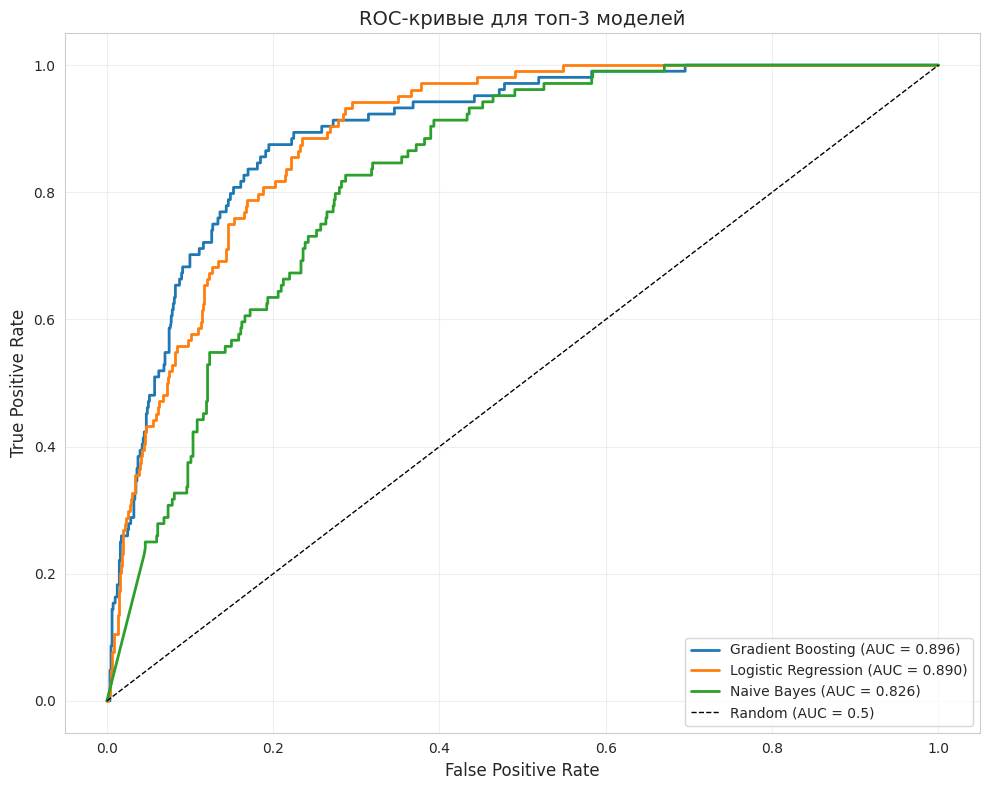

In [ ]:
from sklearn.metrics import roc_curve, auc

# Подготовка данных
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Словарь для топ-3 моделей
top_3_model_objects = {}
for name in top_3_models:
    if name == 'Logistic Regression':
        top_3_model_objects[name] = LogisticRegression(max_iter=1000, random_state=42)
    elif name == 'Random Forest':
        top_3_model_objects[name] = RandomForestClassifier(n_estimators=100, random_state=42)
    elif name == 'Gradient Boosting':
        top_3_model_objects[name] = GradientBoostingClassifier(random_state=42)
    elif name == 'AdaBoost':
        top_3_model_objects[name] = AdaBoostClassifier(random_state=42)
    elif name == 'Decision Tree':
        top_3_model_objects[name] = DecisionTreeClassifier(random_state=42)
    elif name == 'SVM':
        top_3_model_objects[name] = SVC(probability=True, random_state=42)
    elif name == 'KNN':
        top_3_model_objects[name] = KNeighborsClassifier()
    elif name == 'Naive Bayes':
        top_3_model_objects[name] = GaussianNB()

# Построение ROC-кривых
plt.figure(figsize=(10, 8))

for name, model in top_3_model_objects.items():
    model.fit(X_train_scaled, y_train)

    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_proba = model.decision_function(X_test_scaled)

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-кривые для топ-3 моделей', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### ****9.3. Постройте Confusion Matrix для топ-3 моделей****

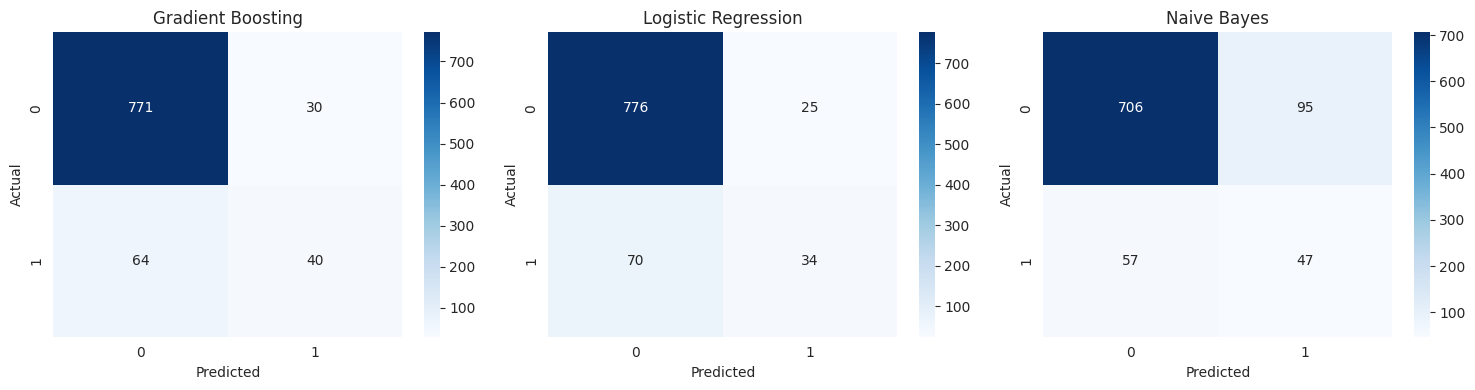

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (name, model) in enumerate(top_3_model_objects.items()):
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'{name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

**Вопрос:** Какая модель лучше всего находит положительный класс (клиентов, которые откроют вклад)?

**Ответ:** среди топ-3 моделей до тюнинга лучше всего положительный класс находит `Naive Bayes`: у него самый высокий recall — 0.4519. Это означает, что он пропускает меньше клиентов, которые действительно открыли вклад, хотя точность положительных предсказаний у него ниже, чем у `Gradient Boosting` и `Logistic Regression`.

---


## ****Часть 10. Оптимизация гиперпараметров с GridSearchCV****

> 📚 **Подсказка:** GridSearchCV перебирает все комбинации гиперпараметров и выбирает лучшую с помощью кросс-валидации.

### ****10.1. Определите сетки гиперпараметров для топ-3 моделей****

In [ ]:
# Сетки гиперпараметров для разных моделей
# Сетки специально небольшие, чтобы GridSearchCV быстро работал в Colab.
param_grids = {
    'Logistic Regression': {
        'C': [0.1, 1, 3],
        'class_weight': [None, 'balanced']
    },
    'Decision Tree': {
        'max_depth': [4, 6, 8, None],
        'min_samples_leaf': [1, 3, 5]
    },
    'Random Forest': {
        'n_estimators': [80],
        'max_depth': [6, 10, None],
        'min_samples_leaf': [1, 3]
    },
    'Gradient Boosting': {
        'n_estimators': [50, 80],
        'learning_rate': [0.05, 0.1],
        'max_depth': [2, 3]
    },
    'AdaBoost': {
        'n_estimators': [50, 80],
        'learning_rate': [0.5, 1.0]
    },
    'SVM': {
        'C': [0.5, 1, 2],
        'gamma': ['scale']
    },
    'KNN': {
        'n_neighbors': [5, 9, 15],
        'weights': ['uniform', 'distance']
    },
    'Naive Bayes': {
        'var_smoothing': [1e-9, 1e-8, 1e-7]
    }
}


### ****10.2. Запустите GridSearchCV для каждой модели из топ-3****

In [ ]:
# Результаты тюнинга
tuning_results = {}

print('=' * 70)
print('GRIDSEARCHCV ДЛЯ ТОП-3 МОДЕЛЕЙ')
print('=' * 70)

for name in top_3_models:
    print()
    print(f'Модель: {name}')
    base_model = clone(models[name])
    grid = GridSearchCV(
        estimator=base_model,
        param_grid=param_grids[name],
        scoring='f1',
        cv=3,
        n_jobs=-1,
        verbose=0
    )
    grid.fit(X_train_scaled, y_train)

    y_pred_tuned = grid.predict(X_test_scaled)
    if hasattr(grid.best_estimator_, 'predict_proba'):
        y_score_tuned = grid.best_estimator_.predict_proba(X_test_scaled)[:, 1]
    elif hasattr(grid.best_estimator_, 'decision_function'):
        y_score_tuned = grid.best_estimator_.decision_function(X_test_scaled)
    else:
        y_score_tuned = None

    tuning_results[name] = {
        'best_estimator': grid.best_estimator_,
        'best_params': grid.best_params_,
        'cv_f1': grid.best_score_,
        'test_accuracy': accuracy_score(y_test, y_pred_tuned),
        'test_precision': precision_score(y_test, y_pred_tuned, zero_division=0),
        'test_recall': recall_score(y_test, y_pred_tuned, zero_division=0),
        'test_f1': f1_score(y_test, y_pred_tuned, zero_division=0),
        'test_roc_auc': roc_auc_score(y_test, y_score_tuned) if y_score_tuned is not None else np.nan
    }

    roc_text = f"{tuning_results[name]['test_roc_auc']:.4f}" if not np.isnan(tuning_results[name]['test_roc_auc']) else 'N/A'
    print(f"Лучшие параметры: {grid.best_params_}")
    print(f"CV F1: {grid.best_score_:.4f}")
    print(f"Test F1: {tuning_results[name]['test_f1']:.4f} | Accuracy: {tuning_results[name]['test_accuracy']:.4f} | ROC-AUC: {roc_text}")

print('=' * 70)


GRIDSEARCHCV ДЛЯ ТОП-3 МОДЕЛЕЙ

Модель: Gradient Boosting
Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 80}
CV F1: 0.4690
Test F1: 0.4419 | Accuracy: 0.8939 | ROC-AUC: 0.8946

Модель: Logistic Regression
Лучшие параметры: {'C': 3, 'class_weight': 'balanced'}
CV F1: 0.5186
Test F1: 0.4865 | Accuracy: 0.8110 | ROC-AUC: 0.8909

Модель: Naive Bayes
Лучшие параметры: {'var_smoothing': 1e-09}
CV F1: 0.4333
Test F1: 0.3821 | Accuracy: 0.8320 | ROC-AUC: 0.8257


### ****10.3. Сравните результаты ДО и ПОСЛЕ тюнинга****

In [ ]:
print("=" * 70)
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ ДО И ПОСЛЕ ТЮНИНГА")
print("=" * 70)

comparison_tuning = []

for name in top_3_models:
    # Результаты до тюнинга
    before = df_comparison_extended[df_comparison_extended['model_name'] == name].iloc[0]

    # Результаты после тюнинга
    after = tuning_results.get(name, {})

    if after:
        comparison_tuning.append({
            'Model': name,
            'F1 (до)': before['f1'],
            'F1 (после)': after['test_f1'],
            'Δ F1': after['test_f1'] - before['f1'],
            'Accuracy (до)': before['accuracy'],
            'Accuracy (после)': after['test_accuracy'],
            'Δ Accuracy': after['test_accuracy'] - before['accuracy']
        })

df_tuning_comparison = pd.DataFrame(comparison_tuning)
print(df_tuning_comparison.to_string(index=False))
print("=" * 70)

СРАВНЕНИЕ РЕЗУЛЬТАТОВ ДО И ПОСЛЕ ТЮНИНГА
              Model  F1 (до)  F1 (после)     Δ F1  Accuracy (до)  Accuracy (после)  Δ Accuracy
  Gradient Boosting 0.441860    0.441860 0.000000       0.893923          0.893923    0.000000
Logistic Regression 0.417178    0.486486 0.069309       0.895028          0.811050   -0.083978
        Naive Bayes 0.382114    0.382114 0.000000       0.832044          0.832044    0.000000


**Вопрос:** Для какой модели тюнинг дал наибольшее улучшение?

**Ответ:** наибольшее улучшение дал тюнинг `Logistic Regression`: F1 вырос с 0.4172 до 0.4865, то есть на +0.0693. При этом accuracy снизилась с 0.8950 до 0.8110, потому что параметр `class_weight='balanced'` заставил модель активнее искать редкий положительный класс `yes`.

**Вопрос:** Какие гиперпараметры оказали наибольшее влияние на качество?

**Ответ:** для лучшей финальной модели (`Logistic Regression`) важнее всего оказались `class_weight='balanced'` и `C=3`. Балансировка классов повысила recall и F1 для редкого класса `yes`; параметр `C` управляет силой регуляризации. Для `Gradient Boosting` лучшими остались `learning_rate=0.1`, `max_depth=3`, `n_estimators=80`, но прироста на тесте они не дали.

---


## ****Часть 11. Финальное сравнение и выводы****

### ****11.1. Постройте итоговую таблицу всех экспериментов****

In [ ]:
# Соберите все эксперименты в одну таблицу
final_summary = []

# Baseline (только числовые признаки)
baseline_results = df_comparison.iloc[0]  # Лучшая модель на baseline
final_summary.append({
    'Эксперимент': 'Baseline (числовые признаки)',
    'Модель': baseline_results['model_name'],
    'Кол-во признаков': len(numeric_cols),
    'F1-Score': baseline_results['f1'],
    'Accuracy': baseline_results['accuracy']
})

# После Feature Engineering
extended_results = df_comparison_extended.iloc[0]
final_summary.append({
    'Эксперимент': 'Feature Engineering + One-Hot',
    'Модель': extended_results['model_name'],
    'Кол-во признаков': X_final.shape[1],
    'F1-Score': extended_results['f1'],
    'Accuracy': extended_results['accuracy']
})

# После тюнинга (лучшая модель)
best_tuned = max(tuning_results.items(), key=lambda x: x[1]['test_f1'])
final_summary.append({
    'Эксперимент': 'После GridSearchCV',
    'Модель': f"{best_tuned[0]} (tuned)",
    'Кол-во признаков': X_final.shape[1],
    'F1-Score': best_tuned[1]['test_f1'],
    'Accuracy': best_tuned[1]['test_accuracy']
})

df_final_summary = pd.DataFrame(final_summary)
print("=" * 80)
print("ИТОГОВАЯ ТАБЛИЦА ЭКСПЕРИМЕНТОВ")
print("=" * 80)
print(df_final_summary.to_string(index=False))
print("=" * 80)

ИТОГОВАЯ ТАБЛИЦА ЭКСПЕРИМЕНТОВ
                  Эксперимент                      Модель  Кол-во признаков  F1-Score  Accuracy
 Baseline (числовые признаки)               Decision Tree                 7  0.404494  0.882873
Feature Engineering + One-Hot           Gradient Boosting                47  0.441860  0.893923
           После GridSearchCV Logistic Regression (tuned)                47  0.486486  0.811050


### ****11.2. Визуализируйте прогресс улучшения модели****

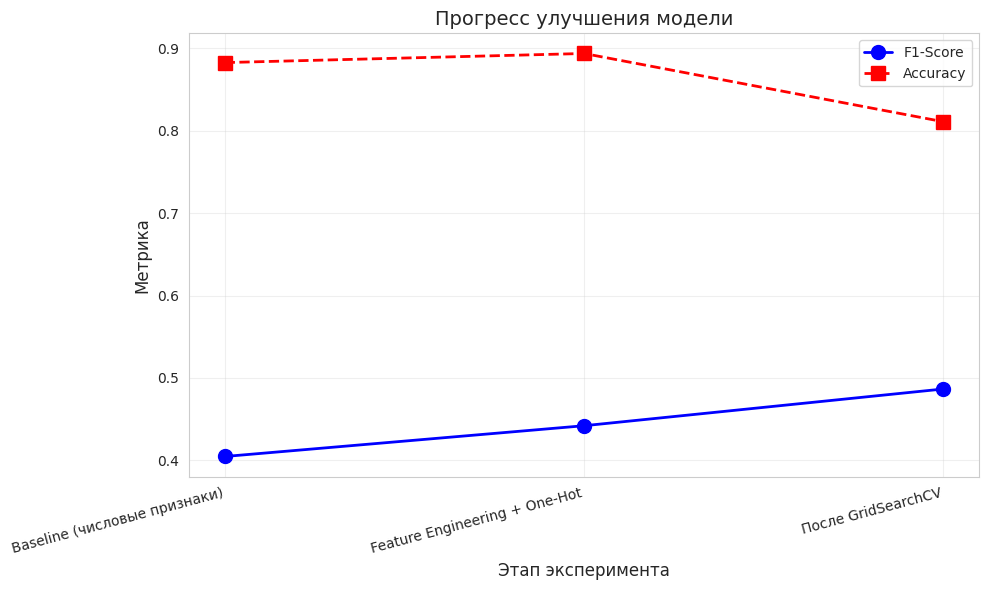


ОБЩИЙ ПРИРОСТ:
F1-Score: 0.4045 → 0.4865 (+0.0820)
Accuracy: 0.8829 → 0.8110 (-0.0718)


In [ ]:
# График прогресса
plt.figure(figsize=(10, 6))

x = range(len(df_final_summary))
plt.plot(x, df_final_summary['F1-Score'], 'bo-', markersize=10, linewidth=2, label='F1-Score')
plt.plot(x, df_final_summary['Accuracy'], 'rs--', markersize=10, linewidth=2, label='Accuracy')

plt.xticks(x, df_final_summary['Эксперимент'], rotation=15, ha='right')
plt.xlabel('Этап эксперимента', fontsize=12)
plt.ylabel('Метрика', fontsize=12)
plt.title('Прогресс улучшения модели', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Прирост
print(f"\nОБЩИЙ ПРИРОСТ:")
print(f"F1-Score: {df_final_summary.iloc[0]['F1-Score']:.4f} → {df_final_summary.iloc[-1]['F1-Score']:.4f} ({df_final_summary.iloc[-1]['F1-Score'] - df_final_summary.iloc[0]['F1-Score']:+.4f})")
print(f"Accuracy: {df_final_summary.iloc[0]['Accuracy']:.4f} → {df_final_summary.iloc[-1]['Accuracy']:.4f} ({df_final_summary.iloc[-1]['Accuracy'] - df_final_summary.iloc[0]['Accuracy']:+.4f})")

### ****11.3. Ответьте на итоговые вопросы****

---

**Вопрос 1:** Какая модель показала лучший финальный результат и почему, по вашему мнению?

**Ответ:** лучший финальный F1-Score показала `Logistic Regression (tuned)` — 0.4865. Она стала лучшей после GridSearchCV, потому что параметр `class_weight='balanced'` помог лучше учитывать редкий положительный класс `yes`, а не только большинство `no`.

---

**Вопрос 2:** Какие признаки оказались шумовыми (ухудшали модель)?

**Ответ:** в простом тесте отдельных признаков хуже всего повлиял `contact_unknown` (-0.0044 к accuracy), немного ухудшил качество `many_contacts_campaign` (-0.0011). По RFE лишними также оказались `age`, `campaign`, `previous`, `day`, `has_positive_balance`, `job_unknown`, `education_unknown`, `many_contacts_campaign`, `balance_per_age`.

---

**Вопрос 3:** Насколько Feature Engineering улучшил результат по сравнению с baseline?

**Ответ:** после Feature Engineering и One-Hot Encoding лучший F1 вырос с 0.4045 до 0.4419, то есть примерно на +0.0374. Accuracy тоже немного выросла: с 0.8829 до 0.8939.

---

**Вопрос 4:** Насколько GridSearchCV улучшил результат? Стоило ли это затраченного времени?

**Ответ:** GridSearchCV улучшил лучший F1 с 0.4419 до 0.4865, прирост составил около +0.0446 относительно этапа Feature Engineering + One-Hot. С учётом небольшой сетки параметров тюнинг стоил затраченного времени, хотя accuracy снизилась из-за большего внимания к классу `yes`.

---

**Вопрос 5:** Какие гиперпараметры оказали наибольшее влияние на качество лучшей модели?

**Ответ:** у лучшей модели (`Logistic Regression`) ключевыми стали `class_weight='balanced'` и `C=3`. `class_weight='balanced'` компенсировал дисбаланс классов, а `C=3` задал подходящую силу регуляризации.

---

**Вопрос 6:** Какие подтвердились из ваших гипотез, сформулированных в Части 4? Какие не подтвердились?

**Ответ:** подтвердилась гипотеза о важности `duration`: это самый важный признак по Random Forest importance (0.2810), и RFE тоже оставил его. Частично подтвердилась гипотеза о предыдущих контактах: `was_contacted` и `poutcome_unknown` улучшили accuracy на +0.0055 и были оставлены RFE. Гипотеза о полезности всех индикаторов пропусков подтвердилась не полностью: `contact_unknown` в отдельном тесте ухудшил accuracy, а `job_unknown` и `education_unknown` почти не дали эффекта.

---

**Вопрос 7:** Что бы вы попробовали ещё для улучшения модели, если бы было больше времени?

**Ответ:** я бы попробовал подобрать порог классификации под бизнес-задачу, отдельно оптимизировать recall для класса `yes`, использовать кросс-валидацию вместо одного train/test split, проверить CatBoost/LightGBM для категориальных признаков и сделать permutation importance для более устойчивой оценки важности признаков.

---


## ****Бонус: Сохранение лучшей модели****

In [ ]:
import joblib

# Сохраняем лучшую модель и scaler
best_model_name = best_tuned[0]
best_model = tuning_results[best_model_name]['best_estimator']

joblib.dump(best_model, 'best_bank_marketing_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print(f"Лучшая модель ({best_model_name}) сохранена в 'best_bank_marketing_model.pkl'")
print("Scaler сохранён в 'scaler.pkl'")


Лучшая модель (Logistic Regression) сохранена в 'best_bank_marketing_model.pkl'
Scaler сохранён в 'scaler.pkl'
